# NB102 - Build the complete 3-modality dataset (DA + polyline + bbox) -> Drive

Assembles, verifies, and packages the full 70k/10k BDD curve subset with all
three GT label modalities, then writes ONE tar.gz to Drive.

| Modality | On disk | Source |
|---|---|---|
| bounding box | `labels/<split>/<stem>.txt` | `BDD_detection_labels.zip` |
| lane polyline | `lane_targets/<split>/<stem>.pt` | `lane_targets_clr_v1_polyline.tar.gz` |
| drivable area | `drivable_masks/<split>/<stem>.png` | **`bdd100k_drivable_maps.zip`** (you provide) |

**PREREQUISITE:** download BDD100K **Drivable Area -> labels (masks)** from
<https://bdd-data.berkeley.edu/> and put the zip at
`/content/drive/MyDrive/EcoCAR/downloads/bdd100k_drivable_maps.zip`.
(NB98's seg-maps zip only matched ~4% of the curve stems - this is the fix.)

**Flow:** Cell 1 mount+deps -> Cell 2 extract images/bbox/polyline to /content/
-> Cell 3 INSPECT the drivable zip structure -> Cell 4 extract DA masks +
coverage report (expect ~100%) -> Cell 5 visual check (DA+polyline+bbox on real
images) -> Cell 6 package the 3 modalities to one tar.gz on Drive.


### Cell 1: Mount Drive + install deps + locate the repo

In [1]:
import os, sys, subprocess
from pathlib import Path

os.environ['PYTHONIOENCODING'] = 'utf-8'
if not Path('/content/drive').exists():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing {REPO_ROOT} -- verify Drive sync.')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
try:
    import cv2  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python-headless'])

MIG     = Path(REPO_ROOT) / 'stage2/rmt_ppad_migration'
PREP    = MIG / 'P8_train/scripts/prepare_bdd_subset.py'
EXTRACT = MIG / 'aux_seg/tools/extract_drivable_subset.py'
FULL    = Path('/content/bdd_dataset')
DOWNLOADS = Path('/content/drive/MyDrive/EcoCAR/downloads')
DATASETS  = Path('/content/drive/MyDrive/EcoCAR/datasets')
for p in (PREP, EXTRACT):
    assert p.exists(), f'missing {p} (sync Drive)'
print('[ok] env ready; repo =', MIG)


Mounted at /content/drive
[ok] env ready; repo = /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration


### Cell 2: Extract images + bbox + polyline to /content/bdd_dataset (70k/10k)

Idempotent (skips if already prepared). Same prep NB97/NB101 use. MUST extract
to /content/ (not Drive) per the small-files rule.


In [2]:
req = [Path('/content/drive/MyDrive/EcoCAR/datasets/bdd100k_clrkd_curve.tar'),
       DOWNLOADS / 'rmt_ppad_weights/BDD_detection_labels.zip',
       Path('/content/drive/MyDrive/EcoCAR/datasets/lane_targets_clr_v1_polyline.tar.gz')]
missing = [str(p) for p in req if not p.exists()]
if missing:
    raise FileNotFoundError('Missing Drive inputs:\n  ' + '\n  '.join(missing))

if (FULL / '.prep_done').exists() or (
        (FULL / 'images/val2017').exists() and any((FULL / 'images/val2017').iterdir())):
    print(f'[ok] subset already at {FULL}; skipping extraction')
else:
    cmd = [sys.executable, '-u', str(PREP), '--out-root', str(FULL),
           '--n-train', '70000', '--n-val', '10000', '--seed', '88']
    print('  ', ' '.join(cmd), flush=True)
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout: print(line, end='', flush=True)
    if p.wait() != 0:
        raise RuntimeError('prep failed - see streamed output above.')
    (FULL / '.prep_done').write_text('ok')

for lab, d in (('images/train', FULL/'images/train2017'), ('images/val', FULL/'images/val2017'),
               ('labels/train', FULL/'labels/train2017'), ('labels/val', FULL/'labels/val2017'),
               ('lane_tgt/train', FULL/'lane_targets/train2017'), ('lane_tgt/val', FULL/'lane_targets/val2017')):
    n = sum(1 for _ in d.iterdir()) if d.exists() else 0
    print(f'  {lab:16s} {n}')


   /usr/bin/python3 -u /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration/P8_train/scripts/prepare_bdd_subset.py --out-root /content/bdd_dataset --n-train 70000 --n-val 10000 --seed 88
  curve_tar   -> /content/drive/MyDrive/EcoCAR/datasets/bdd100k_clrkd_curve.tar
  labels_zip  -> /content/drive/MyDrive/EcoCAR/downloads/rmt_ppad_weights/BDD_detection_labels.zip
  lane_tar    -> /content/drive/MyDrive/EcoCAR/datasets/lane_targets_clr_v1_polyline.tar.gz
[prep] step 1: extract curve tarball
  extracting bdd100k_clrkd_curve.tar -> /content/bdd_curve_scratch
/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration/P8_train/scripts/prepare_bdd_subset.py:72: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(dest)
  done in 163.2s
  curve images: train=/content/bdd_curve_scratch/images/train (70000 jpgs), val=/conte

### Cell 3: Locate + INSPECT the BDD drivable-labels zip (structure only)

Finds the drivable zip on Drive (set `DRIVABLE_ZIP` if it has a different name)
and prints its internal layout + a value histogram, WITHOUT extracting. Confirm
the entries look like `.../drivable/masks/{train,val}/<stem>.png` with values in
{0,1,2} before spending time on extraction.


In [3]:
# Set this if your zip has a different name. Else we auto-search common names.
DRIVABLE_ZIP = DOWNLOADS / 'bdd100k_drivable_maps.zip'
if not DRIVABLE_ZIP.exists():
    cands = []
    if DOWNLOADS.exists():
        for pat in ('*drivable*maps*.zip', '*drivable*labels*.zip', '*drivable*.zip'):
            cands += list(DOWNLOADS.glob(pat))
    cands = sorted(set(cands))
    if cands:
        DRIVABLE_ZIP = cands[0]
        print(f'[auto] using {DRIVABLE_ZIP.name}')
    else:
        raise FileNotFoundError(
            'BDD drivable zip not found under '
            f'{DOWNLOADS}.\nExpected bdd100k_drivable_maps.zip (BDD100K '
            '"Drivable Maps"). Place it there and re-run this cell.')

print(f'[inspect] {DRIVABLE_ZIP}  ({DRIVABLE_ZIP.stat().st_size/1e6:.0f} MB)\n')
subprocess.run([sys.executable, '-u', str(EXTRACT),
                '--seg-zip', str(DRIVABLE_ZIP), '--inspect-only'], check=False)


[inspect] /content/drive/MyDrive/EcoCAR/downloads/bdd100k_drivable_maps.zip  (473 MB)



CompletedProcess(args=['/usr/bin/python3', '-u', '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration/aux_seg/tools/extract_drivable_subset.py', '--seg-zip', '/content/drive/MyDrive/EcoCAR/downloads/bdd100k_drivable_maps.zip', '--inspect-only'], returncode=0)

### Cell 4: Extract drivable masks for ALL subset stems + coverage report

Writes a binary DA mask per stem to `drivable_masks/{train2017,val2017}/`. With
the real BDD label set, coverage should now be ~100% (vs NB98's ~4%). The
extractor prefers the id `masks/` entry over the RGB colormap automatically.


In [4]:
cmd = [sys.executable, '-u', str(EXTRACT),
       '--seg-zip', str(DRIVABLE_ZIP), '--subset-root', str(FULL),
       '--splits', 'train2017', 'val2017']
print('  ', ' '.join(cmd), flush=True)
p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in p.stdout: print(line, end='', flush=True)
rc = p.wait()

# Coverage report per split.
for split in ('train2017', 'val2017'):
    img = FULL/'images'/split
    da  = FULL/'drivable_masks'/split
    n_img = sum(1 for _ in img.glob('*.jpg')) if img.exists() else 0
    have = {q.stem for q in da.glob('*.png')} if da.exists() else set()
    n_da = sum(1 for q in img.glob('*.jpg') if q.stem in have)
    pct = 100*n_da/max(1, n_img)
    flag = '' if pct >= 95 else '   <-- LOW: check Cell 3 inspect output / zip is the right release'
    print(f'  {split}: DA {n_da}/{n_img}  ({pct:.1f}%){flag}')
if rc != 0:
    print(f'[warn] extractor rc={rc} - see output above')


   /usr/bin/python3 -u /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration/aux_seg/tools/extract_drivable_subset.py --seg-zip /content/drive/MyDrive/EcoCAR/downloads/bdd100k_drivable_maps.zip --subset-root /content/bdd_dataset --splits train2017 val2017
[inspect] bdd100k_drivable_maps.zip: 160006 entries, 160000 png
   e.g. color_labels/train/5a0d05c8-09d09545_drivable_color.png
   e.g. color_labels/train/6aa400f6-b6add4b0_drivable_color.png
   e.g. color_labels/train/6e04c802-452bf70f_drivable_color.png
   e.g. color_labels/train/606d46c9-65231a28_drivable_color.png
   e.g. color_labels/train/50cb34ee-f944ff93_drivable_color.png
   e.g. color_labels/train/561a8b88-ed86c6bc_drivable_color.png
   e.g. color_labels/train/50e0558d-3bbb7eff_drivable_color.png
   e.g. color_labels/train/936f90bd-5eb49d68_drivable_color.png
[inspect] first mask color_labels/train/5a0d05c8-09d09545_drivable_color.png unique values: {0: 840802, 29: 30648, 76: 50150}
[train2017] wrote 700

### Cell 5: Visual check - DA + polyline + bbox overlaid on real images

Eyeball that all three modalities are complete and aligned BEFORE packaging:
cyan = drivable area, green = lane polylines, red = vehicle boxes.


showing ['c18d3ffa-befc072e', 'c2f92f94-43481d10', 'b37693d0-cd9bdf88', 'bca3720a-642376aa']


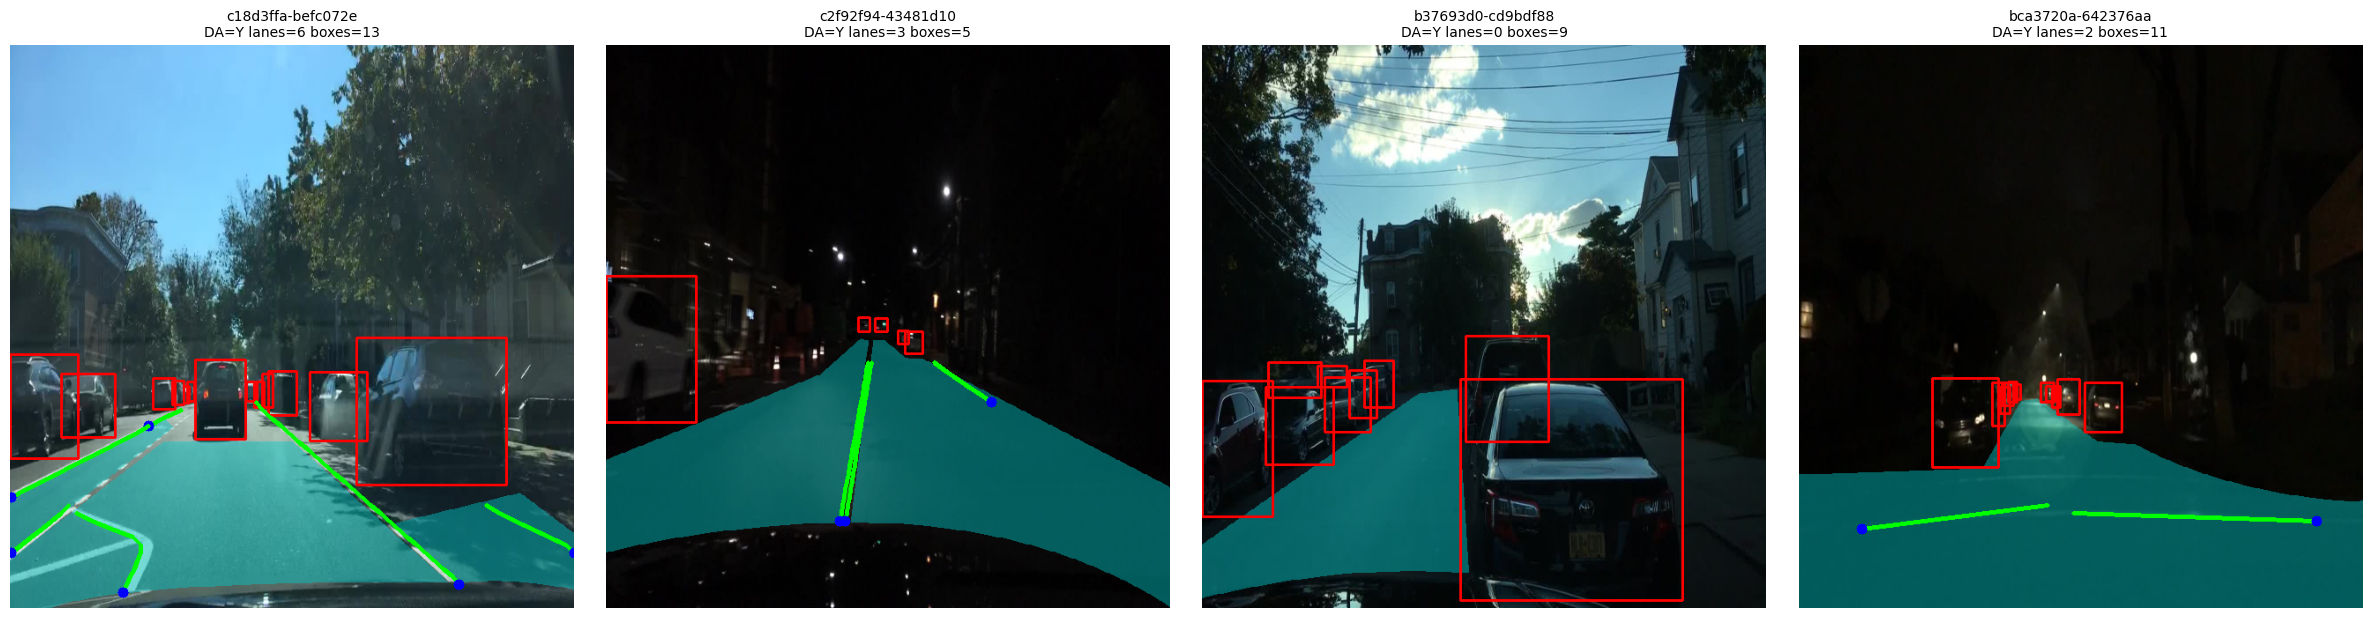

[saved] /content/complete_dataset_check.png
VERDICT: cyan DA on road, green lanes on markings, red boxes on vehicles.


In [5]:
import numpy as np, cv2, torch, random
import matplotlib.pyplot as plt

SPLIT = 'val2017'; N_SHOW = 4; S = 640; NP_, NS = 72, 71
YS = np.arange(S, -1, -S/NS)[:NP_]
img_dir = FULL/'images'/SPLIT; tgt_dir = FULL/'lane_targets'/SPLIT
lbl_dir = FULL/'labels'/SPLIT; da_dir = FULL/'drivable_masks'/SPLIT

def decode_lanes(t):
    out = []
    for row in t:
        if float(row[1]) < 0.5: continue
        start = max(0, min(int(round(float(row[2])*NS)), NP_))
        length = max(0, min(int(round(float(row[5]))), NP_-start))
        if length < 2: continue
        xs = np.asarray(row[6+start:6+start+length], dtype=float); ys = YS[start:start+length]
        pts = [(int(round(x)), int(round(y))) for x, y in zip(xs, ys) if np.isfinite(x) and 0 <= x < S]
        if len(pts) >= 2: out.append(np.array(pts, dtype=np.int32))
    return out

def read_boxes(p):
    bxs = []
    if not p.exists(): return bxs
    for ln in p.read_text().splitlines():
        f = ln.split()
        if len(f) < 5: continue
        cx, cy, w, h = (float(v) for v in f[1:5])
        bxs.append((int((cx-w/2)*S), int((cy-h/2)*S), int((cx+w/2)*S), int((cy+h/2)*S)))
    return bxs

stems = sorted(q.stem for q in img_dir.glob('*.jpg'))
with_da = [s for s in stems if (da_dir/f'{s}.png').exists()]
random.seed(0)
pick = random.sample(with_da, min(N_SHOW, len(with_da))) if with_da else random.sample(stems, min(N_SHOW, len(stems)))
print(f'showing {pick}')

fig, axes = plt.subplots(1, len(pick), figsize=(6*len(pick), 6))
if len(pick) == 1: axes = [axes]
for ax, st in zip(axes, pick):
    img = cv2.cvtColor(cv2.imread(str(img_dir/f'{st}.jpg')), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (S, S)); ov = img.copy()
    da_p = da_dir/f'{st}.png'; has_da = da_p.exists()
    if has_da:
        m = cv2.resize(cv2.imread(str(da_p), cv2.IMREAD_GRAYSCALE), (S, S), interpolation=cv2.INTER_NEAREST) > 0
        tint = ov.copy(); tint[m] = (0, 200, 200); ov = cv2.addWeighted(tint, 0.45, ov, 0.55, 0)
    bxs = read_boxes(lbl_dir/f'{st}.txt')
    for (x1,y1,x2,y2) in bxs: cv2.rectangle(ov, (x1,y1), (x2,y2), (255,0,0), 2)
    lanes = []
    tp = tgt_dir/f'{st}.pt'
    if tp.exists():
        tt = torch.load(tp, weights_only=True)
        t = tt.numpy() if hasattr(tt,'numpy') else np.asarray(tt)
        lanes = decode_lanes(t.astype(np.float32))
        for pts in lanes:
            cv2.polylines(ov, [pts.reshape(-1,1,2)], False, (0,255,0), 3)
            cv2.circle(ov, tuple(pts[0]), 6, (0,0,255), -1)
    ax.imshow(ov); ax.axis('off')
    ax.set_title(f'{st}\nDA={"Y" if has_da else "N"} lanes={len(lanes)} boxes={len(bxs)}', fontsize=10)
plt.tight_layout(); png = '/content/complete_dataset_check.png'; plt.savefig(png, dpi=80); plt.show()
print(f'[saved] {png}\nVERDICT: cyan DA on road, green lanes on markings, red boxes on vehicles.')


### Cell 6: Package the 3 label modalities into ONE tar.gz on Drive

Tars `labels/` + `lane_targets/` + `drivable_masks/` (bbox + polyline + DA) to a
local tar.gz first (fast SSD), then copies the single file to Drive (respects
the small-files rule). Set `INCLUDE_IMAGES=True` for a fully self-contained
bundle (adds ~5 GB of jpgs; off by default since images already live in
`bdd100k_clrkd_curve.tar`). Also writes a manifest JSON with per-modality counts.


In [6]:
import json, shutil

INCLUDE_IMAGES = False        # True -> also bundle images/ (~5 GB, slow)
OUT_NAME = 'bdd_complete_labels_70k' + ('_with_images' if INCLUDE_IMAGES else '')
LOCAL_TAR = Path('/content') / f'{OUT_NAME}.tar.gz'
DRIVE_TAR = DATASETS / f'{OUT_NAME}.tar.gz'
DATASETS.mkdir(parents=True, exist_ok=True)

members = ['labels', 'lane_targets', 'drivable_masks'] + (['images'] if INCLUDE_IMAGES else [])
for m in members:
    if not (FULL/m).exists():
        raise FileNotFoundError(f'missing {FULL/m} - run earlier cells first')

# counts for the manifest
manifest = {'name': OUT_NAME, 'root_layout': 'bdd_dataset/<modality>/<split>/<stem>.<ext>',
            'splits': {}, 'includes_images': INCLUDE_IMAGES}
for split in ('train2017', 'val2017'):
    manifest['splits'][split] = {
        'images':        sum(1 for _ in (FULL/'images'/split).glob('*.jpg')) if (FULL/'images'/split).exists() else 0,
        'labels':        sum(1 for _ in (FULL/'labels'/split).glob('*.txt')) if (FULL/'labels'/split).exists() else 0,
        'lane_targets':  sum(1 for _ in (FULL/'lane_targets'/split).glob('*.pt')) if (FULL/'lane_targets'/split).exists() else 0,
        'drivable_masks':sum(1 for _ in (FULL/'drivable_masks'/split).glob('*.png')) if (FULL/'drivable_masks'/split).exists() else 0,
    }
(FULL/'manifest.json').write_text(json.dumps(manifest, indent=2))
print('[manifest]', json.dumps(manifest['splits'], indent=2))

print(f'\n[tar] {LOCAL_TAR}  (members: {members + ["manifest.json"]})', flush=True)
cmd = ['tar', '-C', str(FULL), '-czf', str(LOCAL_TAR), 'manifest.json', *members]
rc = subprocess.run(cmd).returncode
if rc != 0:
    raise RuntimeError(f'tar failed rc={rc}')
sz = LOCAL_TAR.stat().st_size/1e6
print(f'[tar] done: {sz:.0f} MB')

print(f'[copy] -> {DRIVE_TAR}', flush=True)
shutil.copy2(LOCAL_TAR, DRIVE_TAR)
print(f'[done] complete dataset on Drive: {DRIVE_TAR}  ({DRIVE_TAR.stat().st_size/1e6:.0f} MB)')
print('To reuse: copy this tar to /content and `tar -xzf` it -> bdd_dataset/{labels,lane_targets,drivable_masks}/')


[manifest] {
  "train2017": {
    "images": 70000,
    "labels": 70000,
    "lane_targets": 70000,
    "drivable_masks": 70000
  },
  "val2017": {
    "images": 10000,
    "labels": 10000,
    "lane_targets": 10000,
    "drivable_masks": 10000
  }
}

[tar] /content/bdd_complete_labels_70k.tar.gz  (members: ['labels', 'lane_targets', 'drivable_masks', 'manifest.json'])
[tar] done: 245 MB
[copy] -> /content/drive/MyDrive/EcoCAR/datasets/bdd_complete_labels_70k.tar.gz
[done] complete dataset on Drive: /content/drive/MyDrive/EcoCAR/datasets/bdd_complete_labels_70k.tar.gz  (245 MB)
To reuse: copy this tar to /content and `tar -xzf` it -> bdd_dataset/{labels,lane_targets,drivable_masks}/
